In [1]:
#mounting to google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#checking the files in the directory
import os
print(os.listdir('/content/drive/MyDrive/CamVid_data/'))

['CamVid.rar', 'CamVid']


In [3]:
#checking the files in the directory after extraction
import os
print(os.listdir('/content/drive/MyDrive/CamVid_data/CamVid/'))

['class_dict.csv', 'train_labels', 'val', 'val_labels', 'test', 'test_labels', 'train']


In [4]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/CamVid_data/CamVid/class_dict.csv')
print(df)

                 name    r    g    b
0              Animal   64  128   64
1             Archway  192    0  128
2           Bicyclist    0  128  192
3              Bridge    0  128   64
4            Building  128    0    0
5                 Car   64    0  128
6     CartLuggagePram   64    0  192
7               Child  192  128   64
8         Column_Pole  192  192  128
9               Fence   64   64  128
10       LaneMkgsDriv  128    0  192
11    LaneMkgsNonDriv  192    0   64
12          Misc_Text  128  128   64
13  MotorcycleScooter  192    0  192
14        OtherMoving  128   64   64
15       ParkingBlock   64  192  128
16         Pedestrian   64   64    0
17               Road  128   64  128
18       RoadShoulder  128  128  192
19           Sidewalk    0    0  192
20         SignSymbol  192  128  128
21                Sky  128  128  128
22     SUVPickupTruck   64  128  192
23        TrafficCone    0    0   64
24       TrafficLight    0   64   64
25              Train  192   64  128
2

In [5]:
#creating a dictionary to map the rgb values to class labels
df = pd.read_csv('/content/drive/MyDrive/CamVid_data/CamVid/class_dict.csv')
rgb_to_class={}
for index, rows in df.iterrows():
    rgb = (rows['r'], rows['g'], rows['b'])
    rgb_to_class[rgb] = index
print(rgb_to_class)
print(f"total number of classes: {len(rgb_to_class)}")


{(64, 128, 64): 0, (192, 0, 128): 1, (0, 128, 192): 2, (0, 128, 64): 3, (128, 0, 0): 4, (64, 0, 128): 5, (64, 0, 192): 6, (192, 128, 64): 7, (192, 192, 128): 8, (64, 64, 128): 9, (128, 0, 192): 10, (192, 0, 64): 11, (128, 128, 64): 12, (192, 0, 192): 13, (128, 64, 64): 14, (64, 192, 128): 15, (64, 64, 0): 16, (128, 64, 128): 17, (128, 128, 192): 18, (0, 0, 192): 19, (192, 128, 128): 20, (128, 128, 128): 21, (64, 128, 192): 22, (0, 0, 64): 23, (0, 64, 64): 24, (192, 64, 128): 25, (128, 128, 0): 26, (192, 128, 192): 27, (64, 0, 64): 28, (192, 192, 0): 29, (0, 0, 0): 30, (64, 192, 0): 31}
total number of classes: 32


In [6]:
import numpy as np 
from PIL import Image

def rgbmask_to_class(maskpath):
    mask = np.array(Image.open(maskpath).convert('RGB'))
    class_mask = np.full((mask.shape[0], mask.shape[1]),255,  dtype=np.uint8)
    for rgb, class_label in rgb_to_class.items():
        class_mask[np.all(mask == rgb, axis=-1)] = class_label
    return class_mask


In [7]:
test_mask = rgbmask_to_class('/content/drive/MyDrive/CamVid_data/CamVid/test_labels/0001TP_006690_L.png')
print(test_mask.shape)
print(np.unique(test_mask))

(720, 960)
[ 4  5  8 10 12 14 16 17 19 21 22 24 26 27 30]


In [8]:
# check a specific pixel manually
mask_rgb = np.array(Image.open('/content/drive/MyDrive/CamVid_data/CamVid/test_labels/0001TP_006690_L.png').convert('RGB'))

# pick a pixel, say (100, 100)
pixel = mask_rgb[100, 100]
print(f"RGB at (100,100): {tuple(pixel)}")
print(f"Mapped class: {rgb_to_class.get(tuple(pixel), 'NOT FOUND')}")

RGB at (100,100): (np.uint8(128), np.uint8(0), np.uint8(0))
Mapped class: 4


In [9]:
#loading the data 
import os
import torch
from PIL import Image 
from torch.utils.data import Dataset, DataLoader

class Camviddataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir 
        self.images = os.listdir(image_dir)
        self.mask_dir = mask_dir 
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image_path = os.path.join(self.image_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir,self.images[idx].replace('.png', '_L.png'))
        image = np.array(Image.open(image_path).convert('RGB'))
        mask = rgbmask_to_class(mask_path)
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
        return image, mask.long()

In [10]:
#defining the transformations and using albumentations for data augmentation and normalization , instead of v2 
import albumentations as A
from albumentations.pytorch import ToTensorV2
transform =A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomCrop(height=512, width=512),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
]) 

In [11]:

base = '/content/drive/MyDrive/CamVid_data/CamVid'

sample_test = Camviddataset(
    image_dir=f"{base}/test",
    mask_dir=f"{base}/test_labels",
    transform=transform
)

print(len(sample_test))
image, mask = sample_test[0]
print(image.shape, mask.shape)
print(mask.unique())

232
torch.Size([3, 512, 512]) torch.Size([512, 512])
tensor([ 4,  5,  8, 10, 12, 16, 17, 19, 21, 22, 24, 26, 27, 30])


In [12]:
#creating val_transform and test_transform 
import albumentations as A
from albumentations.pytorch import ToTensorV2
test_transform = A.Compose([
    A.Resize(height=512, width=512),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

In [13]:
#creating datasets
base = '/content/drive/MyDrive/CamVid_data/CamVid'
train_dataset=Camviddataset(image_dir=f"{base}/train",
                            mask_dir=f"{base}/train_labels",
                            transform=transform)
test_datasets=Camviddataset(image_dir=f"{base}/test",
                            mask_dir=f"{base}/test_labels",
                            transform=test_transform)
val_datasets=Camviddataset(image_dir=f"{base}/val",
                           mask_dir=f"{base}/val_labels",
                           transform=test_transform)

print(len(train_dataset), len(test_datasets), len(val_datasets))

369 232 100


In [14]:
#turning into dataloader
from torch.utils.data import dataloader

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0, drop_last=True)
test_loader = DataLoader(test_datasets, batch_size=8, shuffle=False, num_workers=0, drop_last=True)
val_loader = DataLoader(val_datasets, batch_size=8,shuffle=False, num_workers=0, drop_last=True)
print(len(train_loader), len(test_loader), len(val_loader))

46 29 12


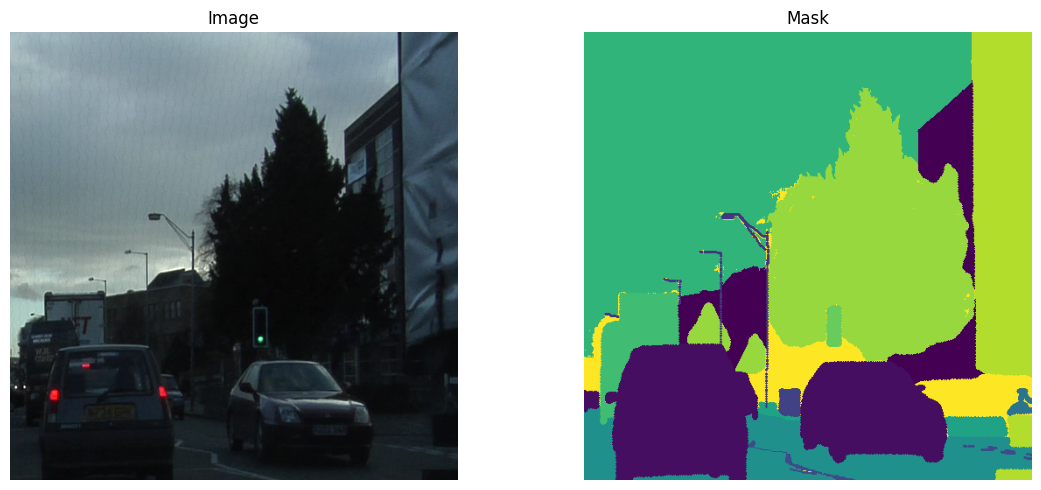

In [15]:
import matplotlib.pyplot as plt

image, mask = train_dataset[0]

# image is a tensor, convert back for plotting
image = image.permute(1, 2, 0).numpy()

# denormalize
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
image = std * image + mean
image = np.clip(image, 0, 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(image)
axes[0].set_title('Image')
axes[0].axis('off')

axes[1].imshow(mask.numpy())
axes[1].set_title('Mask')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#creating Unet from scratch 
import torch 
import torch.nn as nn
 
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU()
        )
    def forward(self, x):
       return self.conv(x)
    
    
class EncoderBlock(nn.Module):
    def __init__(self, in_channels:int, out_channels):
        super().__init__()
        self.conv = DoubleConv(in_channels, out_channels)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
    def forward (self, x):
     skip = self.conv(x)
     pooled = self.pool(skip)
     return skip , pooled
    
#BOTTLENECK 
class Bottleneck(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = DoubleConv(in_channels, out_channels)
    
    def forward(self, x):
        return self.conv(x)

    
    

In [62]:
block = Bottleneck(512, 1024)
x = torch.randn(1, 512, 16, 16)
print(block(x).shape)  # should be (1, 1024, 16, 16)

torch.Size([1, 1024, 16, 16])
